<a href="https://colab.research.google.com/github/springboardmentor891v/CreditPathAI/blob/Vaibhavi/microsoft_preprocessing_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import Libraries (Import libraries)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE
print('✅ Libraries imported successfully! (Import libraries)')

✅ Libraries imported successfully! (Import libraries)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# 2. Acquire the Dataset (Acquire the dataset / Import datasets / Data integration)
df_loan = pd.read_csv('/content/drive/MyDrive/CreditPathAI/Loan.txt', sep='	')
df_borrower = pd.read_csv('/content/drive/MyDrive/CreditPathAI/Borrower.txt', sep='	')
df = pd.merge(df_borrower, df_loan, on='memberId', how='inner')
print('✅ Dataset loaded & merged! Shape:', df.shape)
df.head()

✅ Dataset loaded & merged! Shape: (100000, 27)


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,loanId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,1888978,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,1299695,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,1875016,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,...,1440478,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,...,1124634,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current


In [6]:
# 3. Data Documentation (Data documentation)
df.info()
df.describe(include='all').T
print('✅ Data documented! (Data documentation)')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   memberId                  100000 non-null  int64  
 1   residentialState          100000 non-null  object 
 2   yearsEmployment           100000 non-null  object 
 3   homeOwnership             100000 non-null  object 
 4   annualIncome              100000 non-null  int64  
 5   incomeVerified            100000 non-null  int64  
 6   dtiRatio                  100000 non-null  float64
 7   lengthCreditHistory       100000 non-null  int64  
 8   numTotalCreditLines       100000 non-null  int64  
 9   numOpenCreditLines        99033 non-null   float64
 10  numOpenCreditLines1Year   100000 non-null  int64  
 11  revolvingBalance          100000 non-null  int64  
 12  revolvingUtilizationRate  100000 non-null  float64
 13  numDerogatoryRec          100000 non-null  in

In [7]:
# 4. Data Cleansing (Data cleansing)
df.drop(['memberId', 'loanId'], axis=1, inplace=True)
df.drop_duplicates(inplace=True)
print('✅ Data cleansed! (Data cleansing)')

✅ Data cleansed! (Data cleansing)


In [8]:
# 5. Handling Missing Data (Handling missing data)
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print('✅ Missing data handled! (Handling missing data)')

✅ Missing data handled! (Handling missing data)


/tmp/ipython-input-3938579595.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3938579595.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

/tmp/ipython-input-640632160.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isBad', data=df, palette='Set2')


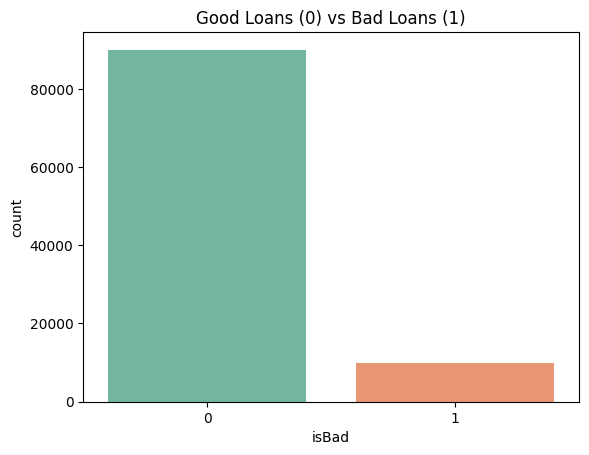

✅ Target variable created! (Data transformation)


In [9]:
# 6. Create Target Variable (Data transformation)
bad_statuses = ['Charged Off', 'Default', 'Charge Off', 'Charged-Off']
df['isBad'] = df['loanStatus'].apply(lambda x: 1 if str(x).strip() in bad_statuses else 0)
df.drop('loanStatus', axis=1, inplace=True)
sns.countplot(x='isBad', data=df, palette='Set2')
plt.title('Good Loans (0) vs Bad Loans (1)')
plt.show()
print('✅ Target variable created! (Data transformation)')

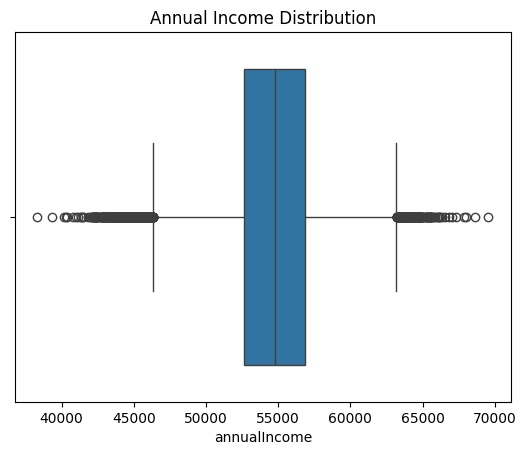

✅ Outliers treated! (Outliers)


In [10]:
# 7. Outlier Detection & Treatment (Outliers)
sns.boxplot(x=df['annualIncome'])
plt.title('Annual Income Distribution')
plt.show()
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))
for col in ['annualIncome','loanAmount','debtToIncome']:
    if col in df.columns:
        cap_outliers(col)
print('✅ Outliers treated! (Outliers)')

In [11]:
# 8. Encoding Categorical Variables (Encoding / Dummy encoding / Categorical data)
df = pd.get_dummies(df, drop_first=True)
print('✅ Categorical data encoded! (Encoding / Dummy encoding / Categorical data)')

✅ Categorical data encoded! (Encoding / Dummy encoding / Categorical data)


In [12]:
# 9. Feature Engineering (Feature engineering / Feature extraction)
if 'annualIncome' in df.columns and 'loanAmount' in df.columns:
    df['income_loan_ratio'] = df['annualIncome'] / (df['loanAmount'] + 1)
print('✅ Feature engineering applied! (Feature engineering / Feature extraction)')

✅ Feature engineering applied! (Feature engineering / Feature extraction)


In [13]:
# 10. Discretization (Discretization)
if 'annualIncome' in df.columns:
    df['income_bins'] = pd.qcut(df['annualIncome'], q=4, labels=['Low','Medium','High','Very High'])
print('✅ Discretization applied! (Discretization)')

✅ Discretization applied! (Discretization)


In [16]:
# 11. Feature Reduction (Data reduction)
X_temp = df.drop(['isBad'], axis=1)
# Drop non-numeric columns before applying PCA
X_temp = X_temp.select_dtypes(exclude=['object', 'category'])
pca = PCA(n_components=5)
pca_features = pca.fit_transform(X_temp)
print('✅ Feature reduction applied! (Data reduction)')

✅ Feature reduction applied! (Data reduction)


In [17]:
# 12. Feature Selection (Feature selection)
selector = SelectKBest(chi2, k=10)
X_new = selector.fit_transform(abs(X_temp), df['isBad'])
print('✅ Feature selection applied! (Feature selection)')

✅ Feature selection applied! (Feature selection)


In [19]:
# 13. Normalization / Feature Scaling (Normalization / Feature scaling)
# Drop non-numeric columns before scaling
df_scaled = df.drop(['isBad', 'income_bins'], axis=1)
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_scaled)
print('✅ Features scaled! (Normalization / Feature scaling)')

✅ Features scaled! (Normalization / Feature scaling)


In [20]:
# 14. Data Splitting (Data splitting)
X = df.drop('isBad', axis=1)
y = df['isBad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print('✅ Data split into Train/Test! (Data splitting)')
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

✅ Data split into Train/Test! (Data splitting)
Train size: (70000, 874) | Test size: (30000, 874)


In [22]:
# 15. Handling Imbalanced Data (Imbalanced data)
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train.select_dtypes(include=np.number), y_train)
print('✅ SMOTE applied! Classes balanced. (Imbalanced data)')
print(y_train_resampled.value_counts())

✅ SMOTE applied! Classes balanced. (Imbalanced data)
isBad
0    62997
1    62997
Name: count, dtype: int64


In [25]:
# 16. Baseline Model (Enhanced model performance)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
model = LogisticRegression(max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test.select_dtypes(include=np.number))
y_prob = model.predict_proba(X_test.select_dtypes(include=np.number))[:,1]
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob))
print('✅ Baseline model trained! (Enhanced model performance)')

Confusion Matrix:
 [[21409  5590]
 [  781  2220]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.79      0.87     26999
           1       0.28      0.74      0.41      3001

    accuracy                           0.79     30000
   macro avg       0.62      0.77      0.64     30000
weighted avg       0.90      0.79      0.82     30000

ROC-AUC Score: 0.8474068528757757
✅ Baseline model trained! (Enhanced model performance)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
